In [1]:
import numpy as np
import xarray as xr
from matplotlib import pyplot as plt
import pandas as pd
from fonts_config import set_computer_modern, truncate_colormap
set_computer_modern()
import matplotlib as mpl
mpl.rcParams['axes.unicode_minus'] = False
import matplotlib.lines as mlines
from matplotlib.patches import Rectangle, Patch, Polygon
import glob
import os
import string
import re
from matplotlib.legend_handler import HandlerTuple
from scipy.stats import gaussian_kde
import seaborn as sns

from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Rectangle
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import matplotlib.container as container

from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as mcolors

import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes



In [2]:
# ---------------------------------------
# paths
# ---------------------------------------
n_best=2572
best=xr.open_dataset(f"/p/projects/megarun/luciagu/data/tabone2024/ensemble_reduced/{n_best}/yelmo2D.nc")
best1=xr.open_dataset(f"/p/projects/megarun/luciagu/data/tabone2024/ensemble_reduced/{n_best}/yelmo1D.nc")
leger=xr.open_dataset("../../FesmData/Leger2024_PaleoGris/output/paleogris_8km.nc")
lgm=xr.open_dataset("/p/projects/megarun/luciagu/data/leger2024/lgm.nc")
lgm_leg = xr.where((lgm.mask==3)|(lgm.mask==2),1,0)
obs = xr.open_dataset("/p/projects/megarun/ice_data/Greenland/GRL-8KM/GRL-8KM_TOPO-M17.nc")
ref=xr.open_dataset("/p/projects/megarun/ice_data/Greenland/GRL-8KM/GRL-8KM_BOX2013_monthly_t2m-1981-2010-pr-1850-2000-corr-all.nc")
temps1 = xr.open_dataset("/p/projects/megarun/luciagu/data/HadCRUT5/HadCRUT.5.0.0.0_analysis_summary-series_global_annual.nc")
temps2 = xr.open_dataset("/p/projects/megarun/luciagu/data/HadCRUT5/HadCRUT.5.0.0.0_analysis_component-series_global_annual.nc")
dist=xr.open_dataset("../output/HTM_distances.nc")



In [3]:
T_jja = best.Ta_sum.mean(axis=1).mean(axis=1)
dT_jja0 = T_jja - T_jja[-1]
dT_jja = best.dTa_sum.mean(axis=1).mean(axis=1)
T_ann = best.Ta_ann.mean(axis=1).mean(axis=1)
dT_ann = best.dTa_ann.mean(axis=1).mean(axis=1)

In [4]:
i = T_jja.argmax()
best.time[i].values

array(-7800., dtype=float32)

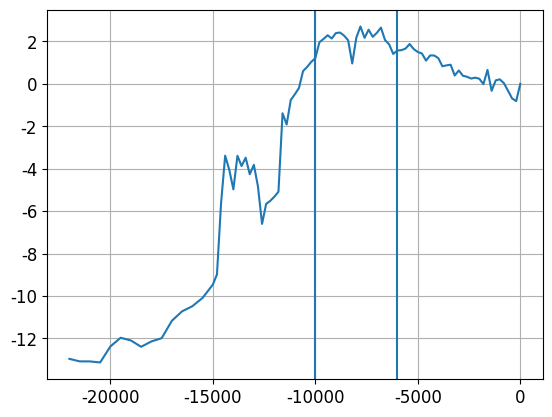

In [5]:
plt.plot(best.time, T_jja-T_jja[-1])
# plt.plot(best.time, dT_jja)

# plt.plot(best.time, T_ann-T_ann[-1])
# plt.plot(best.time, dT_ann)

plt.axvline(x=-6000)
plt.axvline(x=-10000)
plt.grid()

In [3]:

def plot_temp(ax, best, lapse_rate= 0.0065):
    ta_sea_level = best.Ta_sum + (lapse_rate * best.z_srf)
    htm = ta_sea_level.sel(time=slice(-10000, -6000)).mean(axis=0)
    pday = ta_sea_level.sel(time=0)
    pd_z_srf=best.z_srf.sel(time=0)

    anom = htm.values - pday.values
    im = ax.contourf(htm.xc,htm.yc,anom,levels=np.linspace(-4,4,21),cmap="Spectral_r",extend="both")
    cs1 = ax.contour(htm.xc, htm.yc, pd_z_srf, levels=np.arange(0, 100, 1), colors='black',linewidths=0.01)
    print(anom.mean(axis=0).mean(axis=0))
    ax.text(750,-800,"(a)")
    ax.set_aspect(1)
    ax.tick_params(labelbottom=False, labelleft=False)
    return im, anom

def plot_precip(ax, best, lapse_rate= 0):
    ta_sea_level = best.Pr_ann + (lapse_rate * best.z_srf)
    htm = ta_sea_level.sel(time=slice(-10000, -6000)).mean(axis=0)
    pday = ta_sea_level.sel(time=0)
    pd_z_srf=best.z_srf.sel(time=0)

    anom = htm.values - pday.values

    im = ax.contourf(htm.xc,htm.yc,anom,levels=np.linspace(-0.6,0.6,21),cmap="PiYG_r",extend="both")
    cs1 = ax.contour(htm.xc, htm.yc, pd_z_srf, levels=np.arange(0, 100, 1), colors='black',linewidths=0.01)

    ax.text(750,-800,"(b)")
    ax.set_aspect(1)
    ax.tick_params(labelbottom=False, labelleft=False)
    return im


def plot_thick(ax,best,minimal):
    if minimal == 0:
        htm = best.H_ice.sel(time=slice(-10000, -6000)).mean(axis=0)
        label="(c)"
    else:
        htm = best.H_ice.sel(time=-4800)
        label="(d)"
    pday = best.H_ice.sel(time=0)
    pd_z_srf=best.z_srf.sel(time=0)

    anom = htm.values - pday.values

    im = ax.contourf(htm.xc,htm.yc,anom,levels=np.linspace(-1000,1000,21),cmap="bwr_r",extend="both")
    cs1 = ax.contour(htm.xc, htm.yc, pd_z_srf, levels=np.arange(0, 100, 1), colors='black',linewidths=0.01)
    cs1 = ax.contour(htm.xc, htm.yc, pday, levels=np.linspace(0, 10, 1), colors='gray',linewidths=1)
    cs1 = ax.contour(htm.xc, htm.yc, htm, levels=np.linspace(0, 10, 1), colors='black',linewidths=1)

    ax.text(750,-800,label)
    ax.set_aspect(1)
    ax.tick_params(labelbottom=False, labelleft=False)
    return im

<>:29: SyntaxWarning: invalid escape sequence '\D'
<>:40: SyntaxWarning: invalid escape sequence '\D'
<>:51: SyntaxWarning: invalid escape sequence '\D'
<>:29: SyntaxWarning: invalid escape sequence '\D'
<>:40: SyntaxWarning: invalid escape sequence '\D'
<>:51: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_186145/4254845744.py:29: SyntaxWarning: invalid escape sequence '\D'
  cb.set_label('$\Delta \mathrm{T_{JJA}}$ $^{\circ}\mathrm{C}$')
/tmp/ipykernel_186145/4254845744.py:40: SyntaxWarning: invalid escape sequence '\D'
  cb.set_label('$\Delta \mathrm{P_{ann}}$ (m/a w.e.)')
/tmp/ipykernel_186145/4254845744.py:51: SyntaxWarning: invalid escape sequence '\D'
  cb.set_label('$\Delta \mathrm{H_{ice}}$ (m)')


2.1755211


/tmp/ipykernel_186145/4254845744.py:22: UserWarning: Using the axes or figure transform requires a bounding box in the respective coordinates. Using bbox_to_anchor=(0, 0, 1, 1) now.
  axins = inset_axes( ax4,
/tmp/ipykernel_186145/4254845744.py:33: UserWarning: Using the axes or figure transform requires a bounding box in the respective coordinates. Using bbox_to_anchor=(0, 0, 1, 1) now.
  axins = inset_axes( ax4,


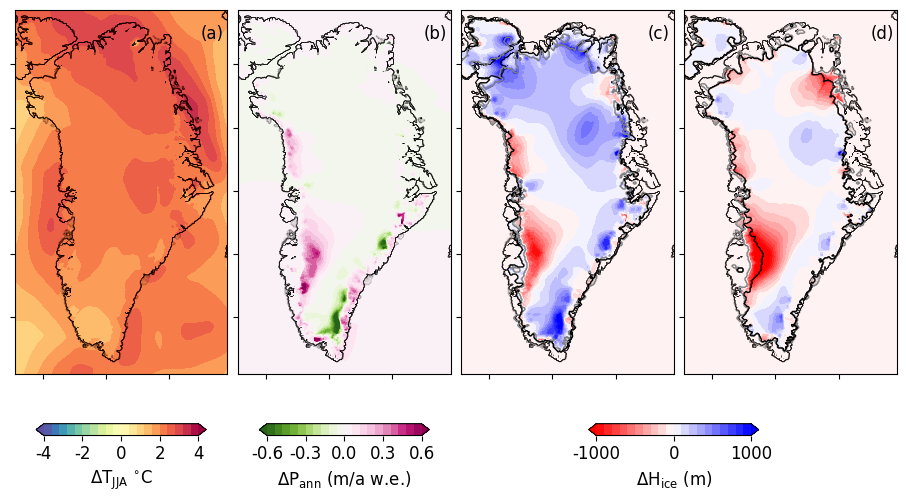

In [4]:
fig = plt.figure(figsize=(9, 5))

gs = gridspec.GridSpec(2, 4,height_ratios=[7, 1])
#  H_ice ---------------------------------------------------------------------
ax1 = plt.subplot(gs[0, 0])
im1,anom_htm_pd = plot_temp(ax1, best, lapse_rate= 0.0065)

ax1 = plt.subplot(gs[0, 1])
im2 = plot_precip(ax1, best, lapse_rate= 0)

ax1 = plt.subplot(gs[0, 2])
im3 = plot_thick(ax1,best,0)

ax1 = plt.subplot(gs[0, 3])
im4 = plot_thick(ax1,best,1)
# Legend and colorbars ------------------------------------------------------

# Leyenda

ax4 = plt.subplot(gs[1, 0])
ax4.axis('off')
axins = inset_axes( ax4,
width="80%",  
height="20%", 
loc="center",
bbox_transform=ax4.transAxes,
borderpad=0)
cb = plt.colorbar(im1, cax=axins, orientation='horizontal',ticks=[-4,-2,0,2,4])
cb.set_label('$\Delta \mathrm{T_{JJA}}$ $^{\circ}\mathrm{C}$')

ax4 = plt.subplot(gs[1, 1])
ax4.axis('off')
axins = inset_axes( ax4,
width="80%",  
height="20%", 
loc="center",
bbox_transform=ax4.transAxes,
borderpad=0)
cb = plt.colorbar(im2, cax=axins, orientation='horizontal',ticks=[-0.6,-0.3,0,0.3,0.6])
cb.set_label('$\Delta \mathrm{P_{ann}}$ (m/a w.e.)')

ax4 = plt.subplot(gs[1, 2:3])
ax4.axis('off')
axins = inset_axes( ax4,
width="80%",  
height="20%", 
loc="center",
bbox_transform=ax4.transAxes,
borderpad=0,bbox_to_anchor=(0.5, 0.0, 1.0, 1.0),)
cb = plt.colorbar(im3, cax=axins, orientation='horizontal',ticks=[-1000,0,1000])
cb.set_label('$\Delta \mathrm{H_{ice}}$ (m)')

plt.subplots_adjust(
        left=0.01,   # Margen izquierdo
        right=0.99,  # Margen derecho
        top=1,    # Margen superior
        bottom=0.05,  # Margen inferior
        wspace=0.05,  
        hspace=0   
        )
plt.savefig(f"../figs_final/fig8_{n_best}_htm_diffs.png",dpi=300)
# plt.close()


In [116]:
anom_htm_pd = xr.Dataset(
    data_vars={"anom": (("yc", "xc"), anom_htm_pd)},
    coords={"xc": best.xc, "yc": best.yc})

In [134]:
T_diff_ocn = anom_htm_pd.anom.where(best.mask_bed.sel(time=0)==0).mean().values
T_diff_green = anom_htm_pd.anom.where(best.mask_bed.sel(time=0)!=0).mean().values
T_diff_dom = anom_htm_pd.anom.mean().values
print(T_diff_ocn)
print(T_diff_green)
print(T_diff_dom)

2.0903103
2.2638555
2.1755211


In [124]:
media_1850_1900 = temps.tas_mean.sel(time=slice('1850', '1900')).mean(dim='time')
media_1981_2010 = temps.tas_mean.sel(time=slice('1981', '2010')).mean(dim='time')

t0 = media_1981_2010.values- media_1850_1900.values
print(t0)

0.7063850179555795


In [135]:
media_1850_1900 = temps2.tas_mean.sel(time=slice('1850', '1900')).mean(dim='time')
media_1980_2000 = temps2.tas_mean.sel(time=slice('1980', '2000')).mean(dim='time')

t0 = media_1980_2000.values- media_1850_1900.values
gmt = T_diff_ocn / 1.19 + t0
print(t0)
print(gmt)

0.6009950381369471
2.357558224782455


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

ts = xr.open_dataset("../output/HTM_ens.nc")
scores = xr.open_dataset("../scoring/scores/scores2.nc")

colors = ["#D9DAB3", "#3C9D9F", "#002665"]
nodes = [0, 0.3, 1.0]
my_cmap = mcolors.LinearSegmentedColormap.from_list("custom_warm", list(zip(nodes, colors)))

x = dist.d_kan.values
y = -ts.dV_sle.values
s = scores.S.values*1e2
z_order = np.argsort(s)
s = s[z_order]
norm = mcolors.Normalize(vmin=s.min(), vmax=s.max())

x = x[z_order]
y = y[z_order]
sigma_puntos = 1 / np.sqrt(s)

# 1. Definir modelo cuadrático
def modelo_2(x, a, b, c):
    return a*x**2 + b*x + c

# 3. Realizar los dos ajustes
# Ajuste Ponderado (Weighted)
popt_w, pcov_w = curve_fit(modelo_2, x, y, sigma=sigma_puntos, absolute_sigma=True)
# Ajuste Sin Pesos (Unweighted / OLS)
popt_ols, pcov_ols = curve_fit(modelo_2, x, y, absolute_sigma=True)

err_w = np.sqrt(np.diag(pcov_w))
err_ols = np.sqrt(np.diag(pcov_ols))

x_fit = np.linspace(0, x.max(), 100)


<>:21: SyntaxWarning: invalid escape sequence '\D'
<>:21: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_503394/2104603050.py:21: SyntaxWarning: invalid escape sequence '\D'
  ax.set_ylabel('$\Delta$GMSL (m)')


Weighted fit: (0.000015 ± 0.000228)$x^2$ + (0.0013 ± 0.0662)$x$ + (0.2498 ± 4.7791)
Unweighted fit: (0.000008 ± 0.000014)$x^2$ + (0.0024 ± 0.0035)$x$ + (0.2551 ± 0.2141)


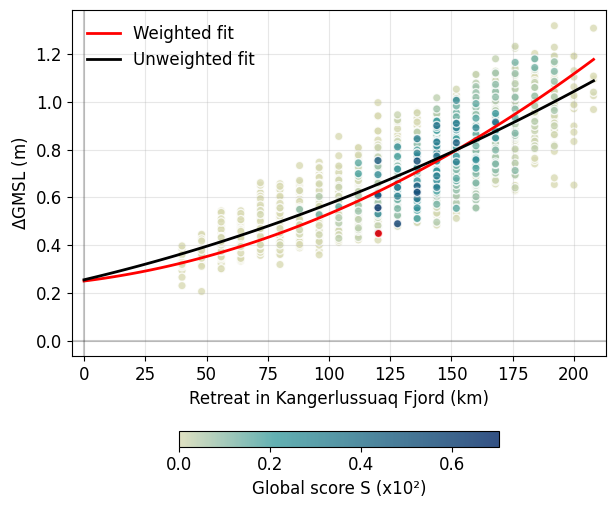

In [5]:

fig, (ax) = plt.subplots(1, 1, figsize=(6, 5), sharey=True)

current_x, label =x, 'Kangerlussuaq Fjord'

scatter = ax.scatter(current_x, y, c=s, cmap=my_cmap, norm=norm, edgecolors='w', alpha=0.8)
ax.scatter(current_x[-1],y[-1], c="red", edgecolors='w', alpha=0.8)
ax.plot(x_fit, modelo_2(x_fit, *popt_w), color='red', lw=2, 
        label=f'Weighted fit')

ax.plot(x_fit, modelo_2(x_fit, *popt_ols), color='black', lw=2, linestyle='-',
        label=f'Unweighted fit')

ax.axvline(x=0,color="black",alpha=0.2)
ax.axhline(y=0,color="black",alpha=0.2)
ax.legend(loc='upper left', frameon=False)
ax.set_xlabel(f'Retreat in {label} (km)')
ax.grid(True, linestyle='-', alpha=0.3)
ax.set_xlim(-5,current_x.max()+5)


ax.set_ylabel('$\Delta$GMSL (m)')
cbar = fig.colorbar(scatter, ax=ax, location='bottom', aspect=20, shrink=0.6,pad=0.15)
cbar.set_label('Global score S (x10²)')
fig.tight_layout()
plt.subplots_adjust(left=0.1, right=0.99, top=0.99, bottom=0)

print(f'Weighted fit: ({popt_w[0]:.6f} ± {err_w[0]:.6f})$x^2$ + ({popt_w[1]:.4f} ± {err_w[1]:.4f})$x$ + ({popt_w[2]:.4f} ± {err_w[2]:.4f})')
print(f'Unweighted fit: ({popt_ols[0]:.6f} ± {err_ols[0]:.6f})$x^2$ + ({popt_ols[1]:.4f} ± {err_ols[1]:.4f})$x$ + ({popt_ols[2]:.4f} ± {err_ols[2]:.4f})')

plt.show()

fig.savefig(f"../figs_final/fig16_{n_best}htm_fit.png", dpi=300)